In [1]:
import os
import time
import pickle
import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime, timedelta
from dotenv import load_dotenv
from sklearn.model_selection import train_test_split, RepeatedStratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, recall_score, precision_score, f1_score,
                             roc_auc_score, average_precision_score,
                             ConfusionMatrixDisplay, PrecisionRecallDisplay)
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline

In [2]:
#1. CONFIGURATION
# The key is read from the NASA_API_KEY environment variable (or a gitignored .env file)
# so it never ends up in the repo.
# Get a free key at https://api.nasa.gov - DEMO_KEY is limited to a few requests per day per IP.
load_dotenv()
API_KEY = os.environ.get('NASA_API_KEY', 'DEMO_KEY')
BASE_URL = "https://api.nasa.gov/neo/rest/v1/feed"
SBDB_URL = "https://ssd-api.jpl.nasa.gov/sbdb_query.api"
DATA_FILE = "nasa_asteroids_big.csv"
WEEKS = 26  # 2023-01-01 to 2023-07-01

# Set to True to download fresh data from the NASA and JPL APIs.
# Otherwise the cached CSV is used, so the results below are reproducible.
REFETCH_DATA = False

FEATURES = ['absolute_magnitude', 'est_diameter_min', 'est_diameter_max',
            'relative_velocity', 'miss_distance', 'moid']

In [3]:
#2. DEFINE DATA FETCHING FUNCTIONS
def fetch_asteroid_data(start_date, end_date):
    """Fetches asteroid data for a specific 7-day window."""
    params = {
        'start_date': start_date,
        'end_date': end_date,
        'api_key': API_KEY
    }
    response = requests.get(BASE_URL, params=params, timeout=30)
    response.raise_for_status()  # Fail loudly rather than silently building a partial dataset

    data = response.json()
    near_earth_objects = data.get('near_earth_objects', {})
    asteroid_list = []

    for date, asteroids in near_earth_objects.items():
        for asteroid in asteroids:
            try:
                # Extract features safely
                close_approach = asteroid['close_approach_data'][0]
                velocity = float(close_approach['relative_velocity']['kilometers_per_hour'])
                miss_distance = float(close_approach['miss_distance']['kilometers'])
                magnitude = float(asteroid['absolute_magnitude_h'])

                # Diameter comes in a range, we'll use the max estimate
                diameter_max = asteroid['estimated_diameter']['kilometers']['estimated_diameter_max']
                diameter_min = asteroid['estimated_diameter']['kilometers']['estimated_diameter_min']

                is_hazardous = asteroid['is_potentially_hazardous_asteroid']

                asteroid_list.append({
                    'id': asteroid['id'],
                    'name': asteroid['name'],
                    'absolute_magnitude': magnitude,
                    'est_diameter_min': diameter_min,
                    'est_diameter_max': diameter_max,
                    'relative_velocity': velocity,
                    'miss_distance': miss_distance,
                    'is_hazardous': is_hazardous
                })
            except (KeyError, IndexError):
                continue # Skip malformed records

    return asteroid_list


def fetch_moid():
    """Earth MOID (au) for every known near-Earth asteroid, from JPL's Small-Body Database.

    MOID (Minimum Orbit Intersection Distance) is the closest the asteroid's orbit ever
    gets to Earth's orbit. NeoWs only returns it from its per-asteroid lookup endpoint
    (one request per asteroid); SBDB returns it for all NEOs in a single request.
    """
    params = {'fields': 'pdes,full_name,moid', 'sb-group': 'neo', 'sb-kind': 'a'}
    response = requests.get(SBDB_URL, params=params, timeout=120)
    response.raise_for_status()

    data = response.json()
    sbdb = pd.DataFrame(data['data'], columns=data['fields'])
    sbdb['moid'] = pd.to_numeric(sbdb['moid'])

    # Asteroids numbered after NeoWs named them are listed as e.g. '749995 (2014 QR295)',
    # so also index each MOID by the provisional designation in brackets
    sbdb['provisional'] = sbdb['full_name'].str.extract(r'\(([^)]+)\)\s*$')[0]
    by_number = sbdb.set_index('pdes')['moid']
    by_provisional = sbdb.dropna(subset=['provisional']).set_index('provisional')['moid']
    moid = pd.concat([by_number, by_provisional])
    return moid[~moid.index.duplicated()]


def designation(neows_name):
    """NeoWs name -> SBDB primary designation: '(2014 QR295)' -> '2014 QR295', '433 Eros (A898 PA)' -> '433'."""
    name = neows_name.strip()
    return name[1:-1] if name.startswith('(') else name.split()[0]

In [4]:
def get_big_dataset():
    """Loops over WEEKS weeks to build a larger dataset, then adds each asteroid's MOID."""
    all_asteroids = []
    start_date = datetime.strptime("2023-01-01", "%Y-%m-%d")

    print("--- Starting Data Collection (This may take about a minute) ---")

    # Fetch WEEKS weeks of data (each window is 7 days, start and end inclusive)
    for i in range(WEEKS):
        end_date = start_date + timedelta(days=6)
        s_str = start_date.strftime("%Y-%m-%d")
        e_str = end_date.strftime("%Y-%m-%d")

        print(f"Fetching Week {i+1}: {s_str} to {e_str}...")
        week_data = fetch_asteroid_data(s_str, e_str)
        all_asteroids.extend(week_data)

        start_date = end_date + timedelta(days=1)
        time.sleep(1) # Be nice to the API

    df = pd.DataFrame(all_asteroids)

    # Some asteroids make two close approaches in the window. Keep one row per asteroid so the
    # same rock can't land in both the training and test data and inflate the scores.
    duplicates = df['id'].duplicated().sum()
    df = df.drop_duplicates(subset='id').reset_index(drop=True)
    print(f"Dropped {duplicates} repeat close approaches (one row per asteroid)")

    print("Fetching MOID for all near-Earth asteroids from JPL SBDB...")
    df['moid'] = df['name'].map(designation).map(fetch_moid())

    missing = df['moid'].isna().sum()
    print(f"MOID found for {len(df) - missing}/{len(df)} asteroids; dropping {missing} without one")
    return df.dropna(subset=['moid'])[['id', 'name', *FEATURES, 'is_hazardous']].reset_index(drop=True)

#3. LOAD DATA (cached CSV, or fetch from the APIs)
if not REFETCH_DATA and os.path.exists(DATA_FILE):
    df = pd.read_csv(DATA_FILE)
    print(f"Loaded cached dataset from '{DATA_FILE}'")
else:
    df = get_big_dataset()
    if len(df) == 0:
        raise RuntimeError("No data collected. Check your API Key.")
    # Save raw data just in case
    df.to_csv(DATA_FILE, index=False)

print(f"\nTotal Asteroids Collected: {len(df)}")
print(f"Hazardous Count: {df['is_hazardous'].sum()}")

Loaded cached dataset from 'nasa_asteroids_big.csv'

Total Asteroids Collected: 1055
Hazardous Count: 103


In [5]:
df.head()

,id,name,absolute_magnitude,est_diameter_min,est_diameter_max,relative_velocity,miss_distance,moid,is_hazardous
0,3683468,(2014 QR295),18.39,0.557898,1.247498,58249.689663,3.933082e+07,0.13500,False
1,3703782,(2015 AE45),25.30,0.023150,0.051765,24703.743910,8.526777e+06,0.03240,False
2,3720918,(2015 LJ),24.70,0.030518,0.068240,25881.197586,6.497596e+07,0.04730,False
3,3767936,(2017 BQ93),20.60,0.201630,0.450858,86987.581071,1.538437e+07,0.02490,True
4,3792438,(2017 XY61),26.20,0.015295,0.034201,29406.941091,2.732201e+07,0.00268,False


In [6]:
df.shape

(1055, 9)

In [7]:
df.isnull().sum()

id                    0
name                  0
absolute_magnitude    0
est_diameter_min      0
est_diameter_max      0
relative_velocity     0
miss_distance         0
moid                  0
is_hazardous          0
dtype: int64

In [8]:
df["is_hazardous"].value_counts()

is_hazardous
False    952
True     103
Name: count, dtype: int64

## Model evaluation

Scoring a model on the same rows it was trained on is misleading: a Random Forest memorises its training data, so it reaches 100% recall there. To get an honest estimate:

1. **Hold out a test set** (20%, stratified so it keeps the ~10% hazardous ratio) that the model never sees while training.
2. **Apply SMOTE only to training data.** Wrapping SMOTE and the classifier in an `imblearn` `Pipeline` means synthetic samples are created during `fit` only, so no synthetic copies of test asteroids leak into training.
3. **Focus on the hazardous class.** With ~90% safe asteroids, accuracy is misleading (always guessing "Safe" scores ~90%). We report **recall** (share of hazardous asteroids caught), **precision** (share of alerts that are real), F1, and PR-AUC.

In [9]:
#4. PREPARE FOR TRAINING
# Separate Features (X) and Target (y); id and name are kept in the CSV for traceability only
X = df[FEATURES]
y = df['is_hazardous']

# Hold out 20% as a test set; stratify=y keeps the hazardous ratio equal in both splits
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

print(f"Train: {len(X_train)} rows ({y_train.sum()} hazardous)")
print(f"Test:  {len(X_test)} rows ({y_test.sum()} hazardous)")

Train: 844 rows (82 hazardous)
Test:  211 rows (21 hazardous)


In [10]:
#5. HANDLE IMBALANCE (SMOTE) INSIDE A PIPELINE
def smote_k(hazardous_count):
    # SMOTE needs k_neighbors < number of hazardous samples.
    # If we found 3 hazardous asteroids, neighbors must be < 3 (so 2).
    # If we found 50, we can use the default 5.
    return 1 if hazardous_count <= 2 else (2 if hazardous_count <= 5 else 5)

def build_model(k):
    # SMOTE runs during fit only, so evaluation data is never oversampled
    return Pipeline([
        ('smote', SMOTE(random_state=42, k_neighbors=k)),
        ('rf', RandomForestClassifier(n_estimators=100, random_state=42)),
    ])

k = smote_k(y_train.sum())
print(f"Using SMOTE with k_neighbors={k}")

Using SMOTE with k_neighbors=5


              precision    recall  f1-score   support

        Safe      1.000     0.995     0.997       190
   Hazardous      0.955     1.000     0.977        21

    accuracy                          0.995       211
   macro avg      0.977     0.997     0.987       211
weighted avg      0.995     0.995     0.995       211

ROC-AUC: 0.999
PR-AUC (average precision): 0.985


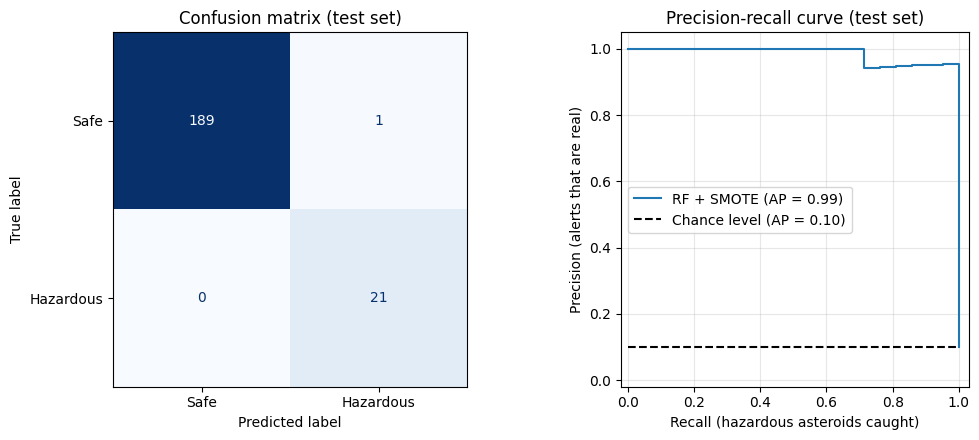

In [11]:
#6. EVALUATE ON THE HELD-OUT TEST SET
eval_model = build_model(k).fit(X_train, y_train)
y_pred = eval_model.predict(X_test)
y_score = eval_model.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred, target_names=['Safe', 'Hazardous'], digits=3))
print(f"ROC-AUC: {roc_auc_score(y_test, y_score):.3f}")
print(f"PR-AUC (average precision): {average_precision_score(y_test, y_score):.3f}")

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, display_labels=['Safe', 'Hazardous'],
                                        cmap='Blues', colorbar=False, ax=axes[0])
axes[0].set_title('Confusion matrix (test set)')
PrecisionRecallDisplay.from_predictions(y_test, y_score, name='RF + SMOTE',
                                        plot_chance_level=True, ax=axes[1])
axes[1].set_title('Precision-recall curve (test set)')
axes[1].set_xlabel('Recall (hazardous asteroids caught)')
axes[1].set_ylabel('Precision (alerts that are real)')
axes[1].set_xlim(-0.02, 1.03)
axes[1].set_ylim(-0.02, 1.05)  # headroom so a near-perfect curve isn't hidden by the frame
axes[1].legend(loc='best')
axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Cross-validation and baselines

The test set holds only a handful of hazardous asteroids, so a single miss moves recall a lot. **Repeated stratified 5-fold cross-validation** (5 folds × 3 repeats = 15 train/test rounds) gives a more stable estimate.

To judge what the model and the MOID feature add, it is compared against baselines on the same folds:
* **RF + SMOTE (no MOID)** — the previous model's feature set, to measure what MOID adds.
* **RF (no SMOTE)** — does oversampling still help?
* **Rule: H ≤ 22** — no machine learning, just flag every asteroid with absolute magnitude ≤ 22.0.
* **Rule: H ≤ 22 and MOID ≤ 0.05 au** — NASA's official definition of a *Potentially Hazardous Asteroid* (PHA).

In [12]:
#7. CROSS-VALIDATION + BASELINES
def score(y_true, pred, prob=None):
    return {
        'recall': recall_score(y_true, pred),
        'precision': precision_score(y_true, pred, zero_division=0),
        'f1': f1_score(y_true, pred),
        'roc_auc': roc_auc_score(y_true, prob) if prob is not None else np.nan,
        'pr_auc': average_precision_score(y_true, prob) if prob is not None else np.nan,
    }

NO_MOID = [f for f in FEATURES if f != 'moid']
models = {
    # name: (model factory, feature columns)
    'RF + SMOTE': (lambda: build_model(k), FEATURES),
    'RF + SMOTE (no MOID)': (lambda: build_model(k), NO_MOID),
    'RF (no SMOTE)': (lambda: RandomForestClassifier(n_estimators=100, random_state=42), FEATURES),
}
rules = {
    'Rule: H <= 22': lambda X: X['absolute_magnitude'] <= 22.0,
    'Rule: H <= 22 and MOID <= 0.05': lambda X: (X['absolute_magnitude'] <= 22.0) & (X['moid'] <= 0.05),
}

cv = RepeatedStratifiedKFold(n_splits=5, n_repeats=3, random_state=42)
rows = []
for fold_train, fold_test in cv.split(X, y):
    X_tr, X_te = X.iloc[fold_train], X.iloc[fold_test]
    y_tr, y_te = y.iloc[fold_train], y.iloc[fold_test]

    for name, (make_model, cols) in models.items():
        model = make_model().fit(X_tr[cols], y_tr)
        rows.append({'model': name, **score(y_te, model.predict(X_te[cols]), model.predict_proba(X_te[cols])[:, 1])})

    for name, rule in rules.items():
        rows.append({'model': name, **score(y_te, rule(X_te))})

cv_results = pd.DataFrame(rows).groupby('model', sort=False).agg(['mean', 'std']).round(3)
cv_results

recall        precision            f1         \
                                 mean    std      mean    std   mean    std   
model                                                                         
RF + SMOTE                      0.980  0.040     0.991  0.019  0.985  0.021   
RF + SMOTE (no MOID)            0.664  0.099     0.378  0.072  0.480  0.082   
RF (no SMOTE)                   0.974  0.040     0.991  0.019  0.982  0.020   
Rule: H <= 22                   1.000  0.000     0.297  0.022  0.457  0.026   
Rule: H <= 22 and MOID <= 0.05  1.000  0.000     0.991  0.019  0.995  0.010   

                               roc_auc        pr_auc         
                                  mean    std   mean    std  
model                                                        
RF + SMOTE                       1.000  0.000  0.999  0.001  
RF + SMOTE (no MOID)             0.914  0.027  0.547  0.120  
RF (no SMOTE)                    0.999  0.002  0.997  0.008  
Rule: H <= 22                      NaN    NaN    NaN    NaN  
Rule: H <= 22 and MOID <= 0.05     NaN    NaN    NaN    NaN

### Takeaways

* **MOID was the missing piece.** Compare *RF + SMOTE* with *RF + SMOTE (no MOID)*: adding it lifts recall and precision from mediocre to near-perfect.
* **The model is learning NASA's definition.** The hazard label is defined as **H ≤ 22.0 and MOID ≤ 0.05 au**, and that two-condition rule scores as well as or better than the Random Forest. The forest approximates the thresholds from examples, so its rare misses sit right on a boundary (H of 21.98–22.00, or MOID of exactly 0.050 au) — plus the stale label below.
* **The rule's only "error" is a stale label.** 2012 KC6 has H = 21.64 and MOID = 0.0489 au, so it meets the definition (JPL's database flags it as a PHA), but its NeoWs flag has not been updated.
* **SMOTE makes little difference now.** Once the deciding feature is present the classes separate cleanly, so oversampling no longer buys much recall.
* **Velocity and miss distance barely matter** (see feature importances below): being a PHA is a property of the orbit, not of one particular flyby. The diameter estimates are computed by NeoWs from H with a fixed albedo range, so they carry the same information as H.

## Train the final model

Evaluation is done, so the deployed model is trained on **all** labelled asteroids. It is saved as a plain `RandomForestClassifier` (SMOTE is only needed during training), so `app.py` only needs scikit-learn to load it.

In [13]:
#8. TRAIN FINAL MODEL ON ALL DATA
final_k = smote_k(y.sum())
print(f"Applying SMOTE (Synthetic Minority Over-sampling) with k_neighbors={final_k}...")
smote = SMOTE(random_state=42, k_neighbors=final_k)
X_resampled, y_resampled = smote.fit_resample(X, y)

print(f"Original shape: {y.value_counts().to_dict()}")
print(f"Resampled shape: {y_resampled.value_counts().to_dict()}")

print("\nTraining Random Forest Model...")
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_resampled, y_resampled)
print("Training Complete!")

Applying SMOTE (Synthetic Minority Over-sampling) with k_neighbors=5...
Original shape: {False: 952, True: 103}
Resampled shape: {False: 952, True: 952}

Training Random Forest Model...
Training Complete!


In [14]:
# Which features does the final model rely on?
pd.Series(rf_model.feature_importances_, index=FEATURES).sort_values(ascending=False).round(3)

moid                  0.332
absolute_magnitude    0.217
est_diameter_min      0.212
est_diameter_max      0.183
relative_velocity     0.028
miss_distance         0.027
dtype: float64

In [15]:
#9. SAVE MODEL (PICKLE)
filename = 'asteroid_hazard_model.pkl'
with open(filename, 'wb') as file:
    pickle.dump(rf_model, file)

print(f"SUCCESS: Model saved to '{filename}'")

#10. VERIFY (TEST LOAD)
print("\n--- Verifying Saved Model ---")
with open(filename, 'rb') as file:
    loaded_model = pickle.load(file)

# Fake asteroids for testing (a DataFrame keeps the feature names the model was trained with)
test_asteroids = pd.DataFrame([[20.5, 0.2, 0.45, 55000, 1200000, 0.02],   # bright, orbit passes close to Earth's
                               [20.5, 0.2, 0.45, 55000, 1200000, 0.30]],  # same rock, distant orbit
                              columns=FEATURES)
for moid, pred in zip(test_asteroids['moid'], loaded_model.predict(test_asteroids)):
    print(f"Test Prediction for rock with MOID {moid} au: {'HAZARDOUS' if pred else 'Safe'}")

SUCCESS: Model saved to 'asteroid_hazard_model.pkl'

--- Verifying Saved Model ---
Test Prediction for rock with MOID 0.02 au: HAZARDOUS
Test Prediction for rock with MOID 0.3 au: Safe
